In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import pickle, warnings, os
warnings.filterwarnings('ignore')

## Phase 1: Basic Statistic

Load Data

In [143]:
DATA_DIR = 'dataset/'

X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
Y_train = pd.read_csv(os.path.join(DATA_DIR, 'Y_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_DIR, 'X_val.csv'))
Y_val   = pd.read_csv(os.path.join(DATA_DIR, 'Y_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
TARGET_COLS = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']

print(f'X_train : {X_train.shape}')
print(f'Y_train : {Y_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
X_train.head(3)

X_train : (51000, 38)
Y_train : (51000, 7)
X_val   : (7200, 38)
X_test  : (38000, 38)


,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37
0,cu2xz,109,4275,15342,977.0,103.0,109.0,114.0,849.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,uv203,685,2207,8615,886.0,103.0,685.0,1464.0,21355.0,1071.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,rwa6i,10477,697,1455,102.0,15881.0,1027.0,7362.0,2621.0,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Tách Meta cols vs Sequence cols
> Nhìn vào null pattern: cột nào luôn có giá trị = metadata cố định của user

Meta cols (8): ['id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7']
Seq cols  (30): feature_8 ... feature_37


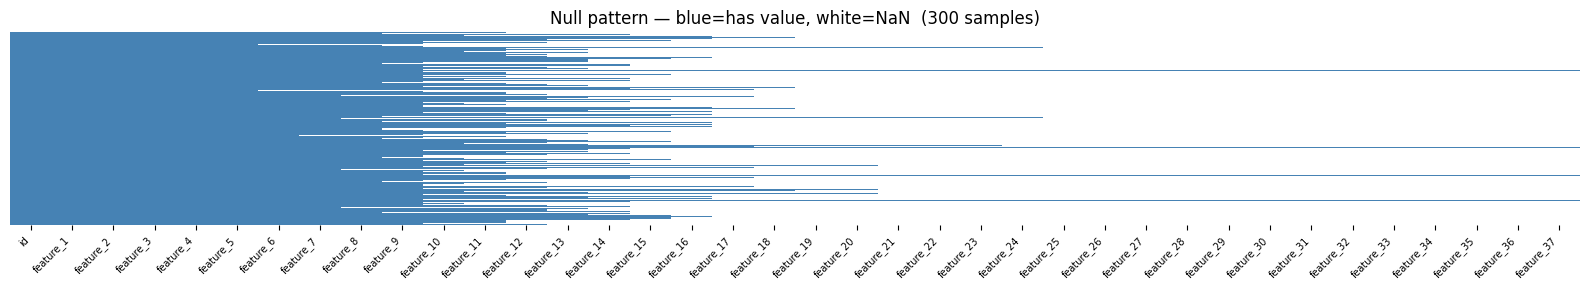


=== Meta cols unique values ===
  id: 51000 unique | top5: {'f6oqr': 1, 'cu2xz': 1, 'uv203': 1, 'rwa6i': 1, 'lzxxq': 1}
  feature_1: 120 unique | top5: {760: 8227, 685: 7919, 836: 4153, 7943: 4116, 10477: 4104}
  feature_2: 107 unique | top5: {105: 7233, 1165: 4156, 697: 4104, 1593: 4071, 2207: 4033}
  feature_3: 167 unique | top5: {8615: 8104, 105: 6848, 102: 4655, 21355: 1149, 20022: 1149}
  feature_4: 182 unique | top5: {105.0: 8864, 102.0: 5886, 103.0: 1768, 1749.0: 1724, 906.0: 1119}
  feature_5: 189 unique | top5: {103.0: 5703, 606.0: 4021, 102.0: 3623, 105.0: 2323, 694.0: 1840}
  feature_6: 193 unique | top5: {103.0: 4885, 867.0: 2428, 929.0: 2353, 24438.0: 2108, 105.0: 1728}
  feature_7: 195 unique | top5: {103.0: 4773, 105.0: 3239, 24438.0: 2615, 735.0: 2537, 697.0: 2013}


In [144]:
null_pct  = X_train.isnull().mean() * 100
meta_cols = [c for c in X_train.columns if null_pct[c] < 1.0]
seq_cols  = [c for c in X_train.columns if null_pct[c] >= 1.0]

print(f'Meta cols ({len(meta_cols)}): {meta_cols}')
print(f'Seq cols  ({len(seq_cols)}): {seq_cols[0]} ... {seq_cols[-1]}')

# Null heatmap
fig, ax = plt.subplots(figsize=(16,3))
sample = np.random.choice(len(X_train), min(300, len(X_train)), replace=False)
sns.heatmap(X_train.iloc[sample].isnull().values,
            cmap=['steelblue','white'], cbar=False, ax=ax,
            xticklabels=list(X_train.columns), yticklabels=False)
ax.set_title('Null pattern — blue=has value, white=NaN  (300 samples)')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout(); plt.show()

# Meta cols unique values
print('\n=== Meta cols unique values ===')
for c in meta_cols:
    print(f'  {c}: {X_train[c].nunique()} unique | top5: {X_train[c].value_counts().head(5).to_dict()}')

Convert rows → sequences

In [145]:
print(X_train.head())
print(X_train.columns)

      id  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0  cu2xz        109       4275      15342      977.0      103.0      109.0   
1  uv203        685       2207       8615      886.0      103.0      685.0   
2  rwa6i      10477        697       1455      102.0    15881.0     1027.0   
3  lzxxq        685       1464        102    17980.0     1104.0      103.0   
4  lqeic      10477        697       1126      102.0    15342.0     1104.0   

   feature_7  feature_8  feature_9  ...  feature_28  feature_29  feature_30  \
0      114.0      849.0        NaN  ...         NaN         NaN         NaN   
1     1464.0    21355.0     1071.0  ...         NaN         NaN         NaN   
2     7362.0     2621.0      166.0  ...         NaN         NaN         NaN   
3      760.0     1165.0      102.0  ...         NaN         NaN         NaN   
4      606.0      760.0     1165.0  ...         NaN         NaN         NaN   

   feature_31  feature_32  feature_33  feature_34  featu

In [146]:
feature_cols = [col for col in X_train.columns if col.startswith("feature_")]

In [147]:
def clean_actions(df):
    
    feature_cols = [col for col in df.columns if col.startswith("feature_")]
    
    for col in feature_cols:
        df[col] = (
            pd.to_numeric(df[col], errors="coerce")  # đảm bảo numeric
            .fillna(0)                               # padding
            .astype(int)                             # float -> int
        )
        
    return df

In [148]:
X_train = clean_actions(X_train)
X_val = clean_actions(X_val)
X_test = clean_actions(X_test)

In [149]:
print(X_train[feature_cols].dtypes.head())

feature_1    int64
feature_2    int64
feature_3    int64
feature_4    int64
feature_5    int64
dtype: object


In [150]:
def row_to_seq(row):
    return [int(v) for v in row[seq_cols].values if v != 0]

In [151]:
print('Converting sequences...')

train_seqs = X_train.apply(row_to_seq, axis=1).values
val_seqs   = X_val.apply(row_to_seq, axis=1).values
test_seqs  = X_test.apply(row_to_seq, axis=1).values

print(f'Done. Sample: len={len(train_seqs[0])}, values={train_seqs[0][:8]}...')

Converting sequences...
Done. Sample: len=1, values=[849]...


Sequence Length Distribution

SEQUENCE LENGTH STATS (TRAIN)
count    51000.000000
mean         5.826294
std          4.577351
min          0.000000
10%          2.000000
25%          2.000000
50%          5.000000
75%          8.000000
90%         10.000000
95%         12.000000
99%         30.000000
max         30.000000


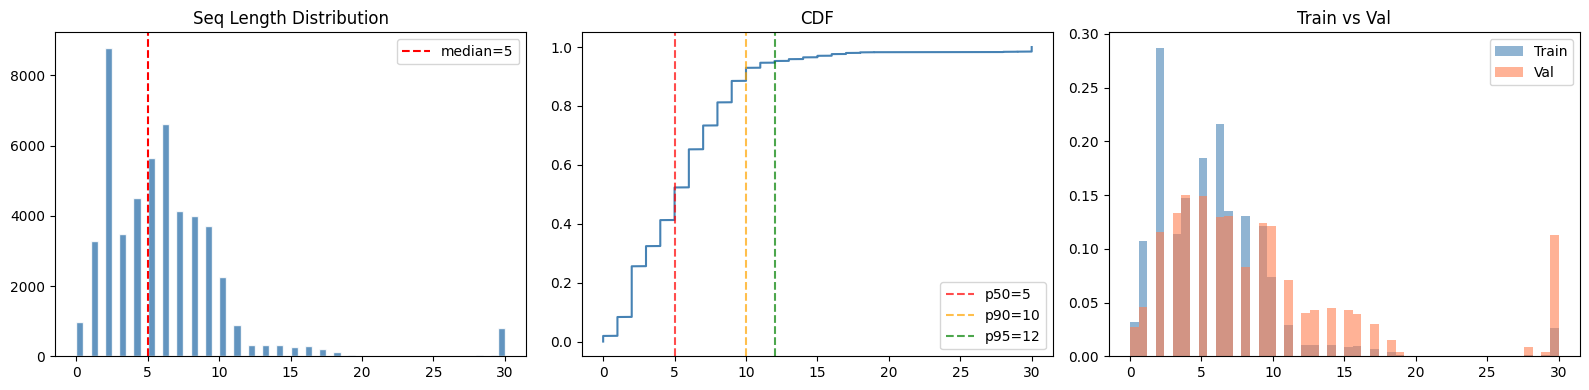


p95 length (dùng làm MAX_LEN): 12


In [152]:
lengths_tr = np.array([len(s) for s in train_seqs])
lengths_vl = np.array([len(s) for s in val_seqs])

print('SEQUENCE LENGTH STATS (TRAIN)')
print(pd.Series(lengths_tr).describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())

fig, axes = plt.subplots(1,3, figsize=(16,4))
axes[0].hist(lengths_tr, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(lengths_tr), color='red', linestyle='--', label=f'median={np.median(lengths_tr):.0f}')
axes[0].set_title('Seq Length Distribution'); axes[0].legend()

sorted_l = np.sort(lengths_tr)
axes[1].plot(sorted_l, np.arange(1,len(sorted_l)+1)/len(sorted_l), 'steelblue')
for p,c in [(50,'red'),(90,'orange'),(95,'green')]:
    xp = np.percentile(lengths_tr,p)
    axes[1].axvline(xp, color=c, linestyle='--', alpha=.7, label=f'p{p}={xp:.0f}')
axes[1].set_title('CDF'); axes[1].legend()

axes[2].hist(lengths_tr, bins=50, alpha=.6, label='Train', color='steelblue', density=True)
axes[2].hist(lengths_vl, bins=50, alpha=.6, label='Val',   color='coral',     density=True)
axes[2].set_title('Train vs Val'); axes[2].legend()
plt.tight_layout(); plt.show()

MAX_LEN_P95 = int(np.percentile(lengths_tr, 95))
print(f'\np95 length (dùng làm MAX_LEN): {MAX_LEN_P95}')

In [153]:
sum(len(s) == 0 for s in train_seqs)

974

Vocabulary Analysis

Total tokens (w/ repeat): 297,141
Unique token types:       236
Token range:              102 – 24438
Top 20: [(105, 26243), (102, 24048), (8615, 9243), (103, 8200), (697, 6852), (975, 6139), (760, 6114), (1068, 5606), (685, 5369), (21355, 4754), (15342, 4739), (21606, 4715), (17980, 4714), (21040, 4664), (20278, 4638), (20022, 4553), (15881, 4310), (1027, 4110), (995, 4104), (1080, 4100)]

Very common (>10% sessions): 9 → likely action types: [102, 103, 105, 685, 697, 760, 975, 1068, 8615]
Common (1-10%):              98
Rare (<1%):                  129 → likely product/order IDs


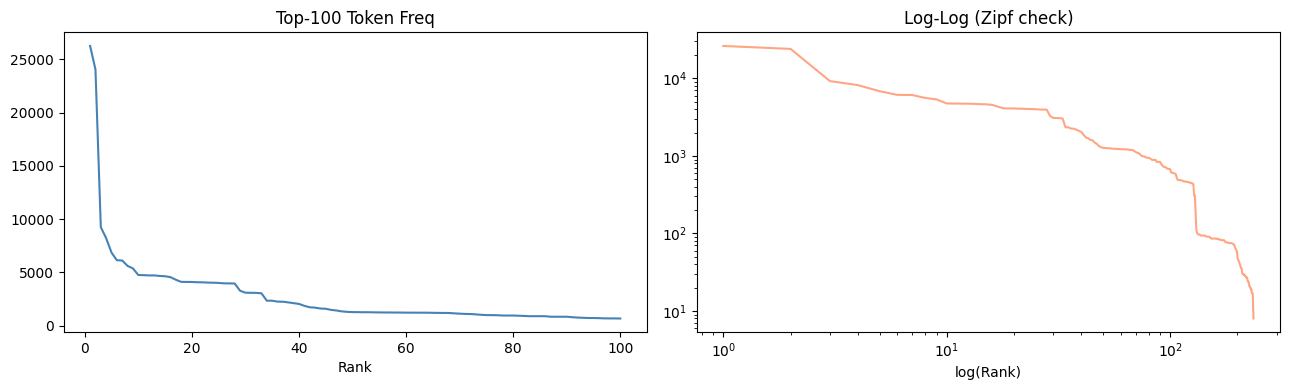

In [154]:
all_tokens    = [t for s in train_seqs for t in s]
token_counter = Counter(all_tokens)
N_train       = len(train_seqs)

print(f'Total tokens (w/ repeat): {len(all_tokens):,}')
print(f'Unique token types:       {len(token_counter):,}')
print(f'Token range:              {min(token_counter)} – {max(token_counter)}')
print(f'Top 20: {token_counter.most_common(20)}')

very_common = {t for t,f in token_counter.items() if f/N_train > 0.10}
common      = {t for t,f in token_counter.items() if 0.01 < f/N_train <= 0.10}
rare        = {t for t,f in token_counter.items() if f/N_train <= 0.01}
print(f'\nVery common (>10% sessions): {len(very_common)} → likely action types: {sorted(very_common)}')
print(f'Common (1-10%):              {len(common)}')
print(f'Rare (<1%):                  {len(rare):,} → likely product/order IDs')

freqs = sorted(token_counter.values(), reverse=True)
ranks = np.arange(1, len(freqs)+1)
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].plot(ranks[:100], freqs[:100], 'steelblue')
axes[0].set_title('Top-100 Token Freq'); axes[0].set_xlabel('Rank')
axes[1].loglog(ranks, freqs, 'coral', alpha=.7)
axes[1].set_title('Log-Log (Zipf check)'); axes[1].set_xlabel('log(Rank)')
plt.tight_layout(); plt.show()

Target Distribution

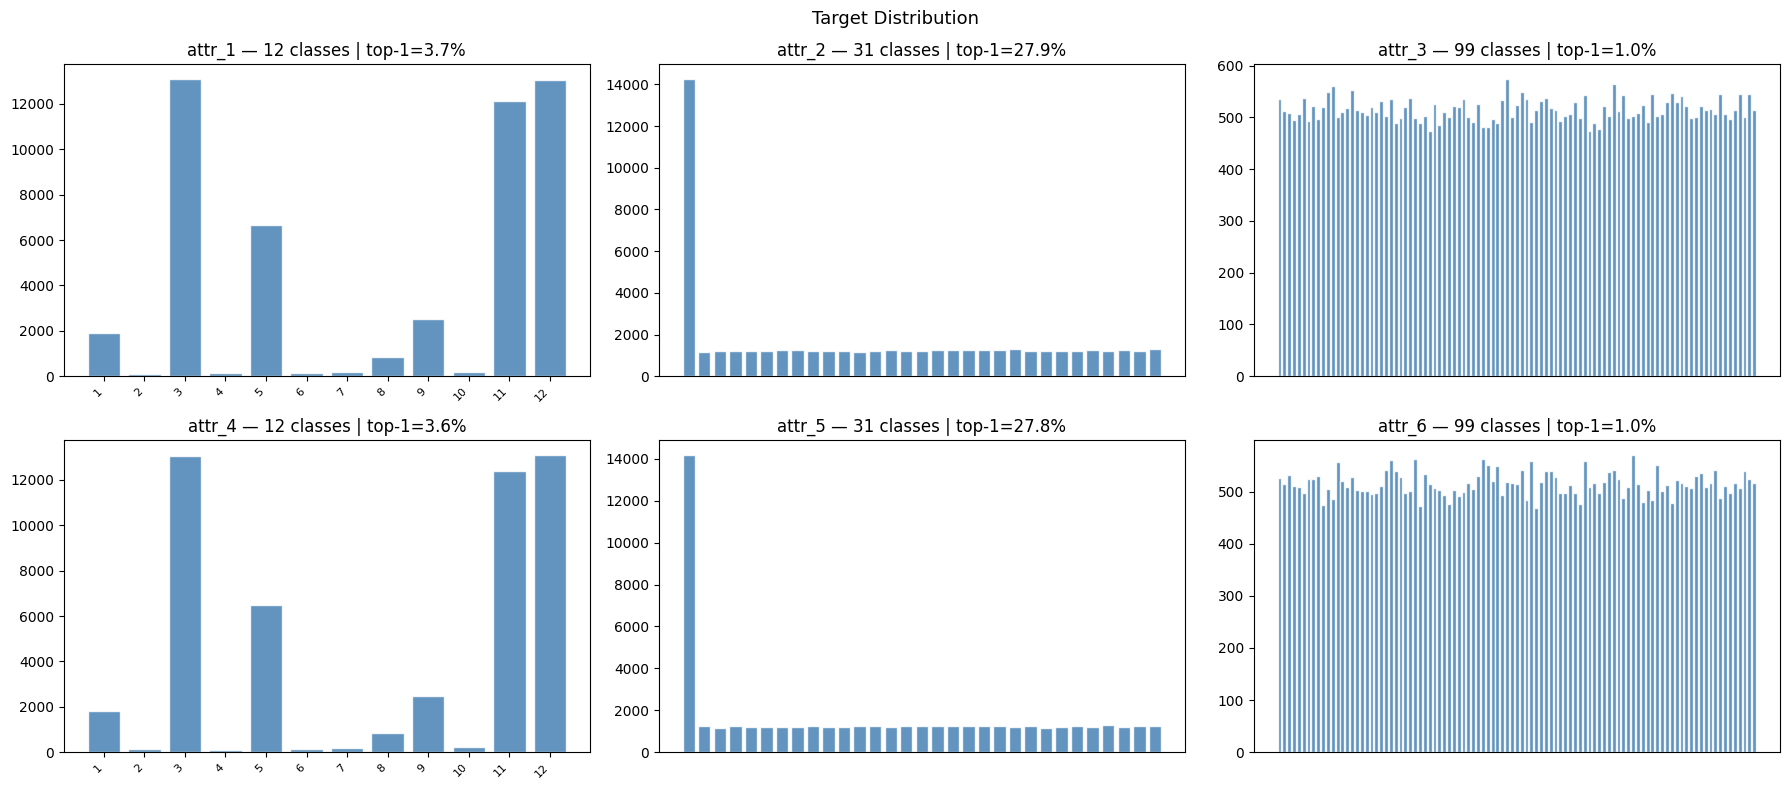

CLASS COUNT & IMBALANCE
  attr_1:  12 classes | top-1=25.7% ok
  attr_2:  31 classes | top-1=27.9% ok
  attr_3:  99 classes | top-1=1.1% ok
  attr_4:  12 classes | top-1=25.7% ok
  attr_5:  31 classes | top-1=27.8% ok
  attr_6:  99 classes | top-1=1.1% ok


In [155]:
fig, axes = plt.subplots(2,3, figsize=(18,8))
for i, col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    vc = Y_train[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white', alpha=.85)
    top1 = vc.iloc[0]/len(Y_train)*100
    ax.set_title(f'{col} — {Y_train[col].nunique()} classes | top-1={top1:.1f}%')
    if Y_train[col].nunique() > 20: ax.set_xticks([])
    else: plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.suptitle('Target Distribution', fontsize=13)
plt.tight_layout(); plt.show()

print('CLASS COUNT & IMBALANCE')
for col in TARGET_COLS:
    vc = Y_train[col].value_counts()
    flag = 'IMBALANCED' if vc.iloc[0]/len(Y_train) > 0.5 else 'ok'
    print(f'  {col}: {Y_train[col].nunique():3d} classes | top-1={vc.iloc[0]/len(Y_train)*100:.1f}% {flag}')

Target Correlation

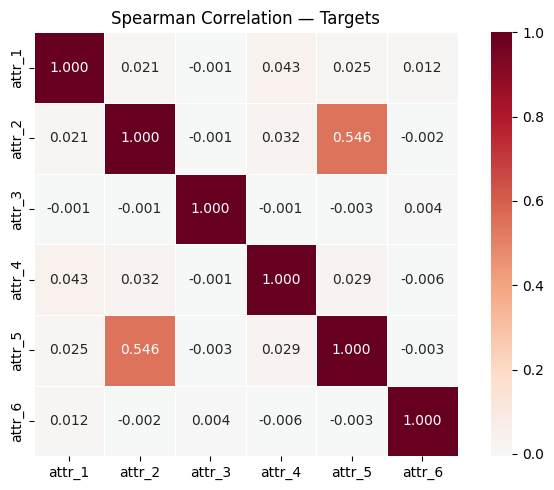

High correlation pairs (|r|>0.3):
  attr_2 ↔ attr_5: 0.546 => khai thác stacking


In [156]:
corr = Y_train[TARGET_COLS].rank().corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5)
plt.title('Spearman Correlation — Targets')
plt.tight_layout(); plt.show()
print('High correlation pairs (|r|>0.3):')
for i in range(len(TARGET_COLS)):
    for j in range(i+1, len(TARGET_COLS)):
        r = corr.iloc[i,j]
        if abs(r) > 0.3:
            print(f'  {TARGET_COLS[i]} ↔ {TARGET_COLS[j]}: {r:.3f} => khai thác stacking')

In [157]:
from collections import Counter

token_counter_train = Counter(
    token for seq in train_seqs for token in seq
)

token_counter_test = Counter(
    token for seq in test_seqs for token in seq
)

In [158]:
train_vocab = set(token_counter_train.keys())
test_vocab = set(token_counter_test.keys())

overlap = len(train_vocab & test_vocab) / len(test_vocab)

print("Train vocab size:", len(train_vocab))
print("Test vocab size:", len(test_vocab))
print("Token overlap:", overlap)
print("OOV rate:", 1 - overlap)

Train vocab size: 236
Test vocab size: 227
Token overlap: 1.0
OOV rate: 0.0




Điều này có nghĩa là toàn bộ các action token xuất hiện trong tập test đều đã từng xuất hiện trong tập train. Tuy OOV = 0% về type nhưng distribution của token frequency vẫn shift nên vẫn cần KFold.

Cụ thể, tỉ lệ overlap giữa vocabulary của train và test là 100%, và không có token nào trong test là hoàn toàn mới (OOV – Out Of Vocabulary) so với train.



## Phase 2: Behavioral Pattern Analysis

Seq_len vs targets

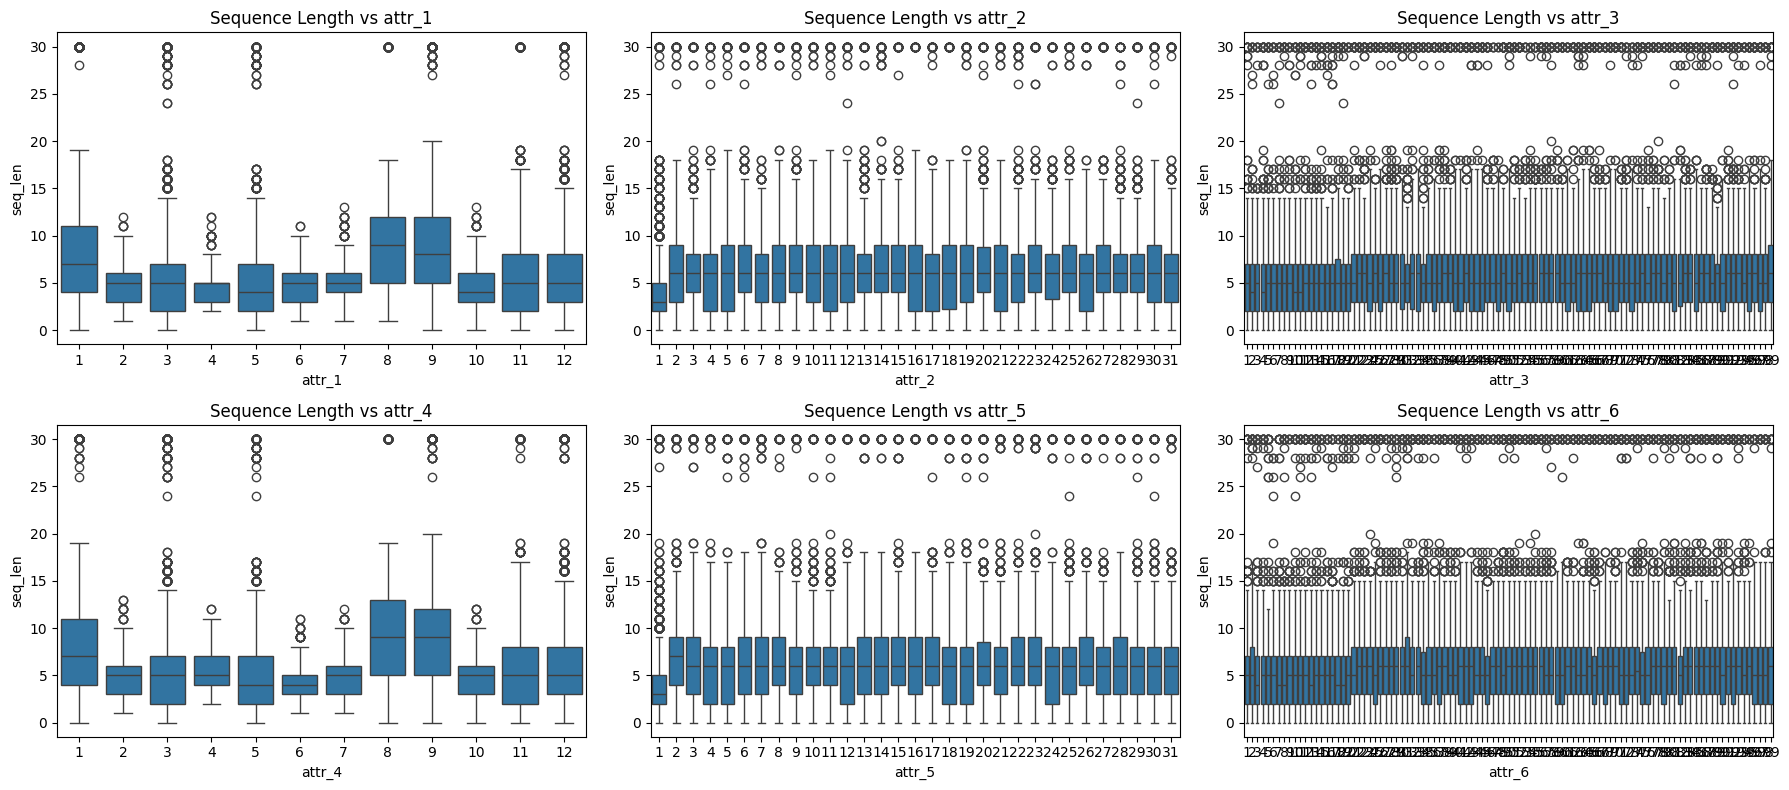

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

train_df = X_train.merge(Y_train, on="id")

train_df["seq_len"] = (train_df[seq_cols] != 0).sum(axis=1)

fig, axes = plt.subplots(2,3, figsize=(18,8))

for i,col in enumerate(TARGET_COLS):
    ax = axes[i//3][i%3]
    sns.boxplot(x=train_df[col], y=train_df["seq_len"], ax=ax)
    ax.set_title(f"Sequence Length vs {col}")

plt.tight_layout()

Note: sequence length có giá trị với attr_1 và attr_4, không mang nhiều ý nghĩa với attr_2 và attr_5 (box plot chồng lên nhau nhiều). attr_3 và attr_6 quá nhiều giá trị nên boxplot rối, không có giá trị phân tích

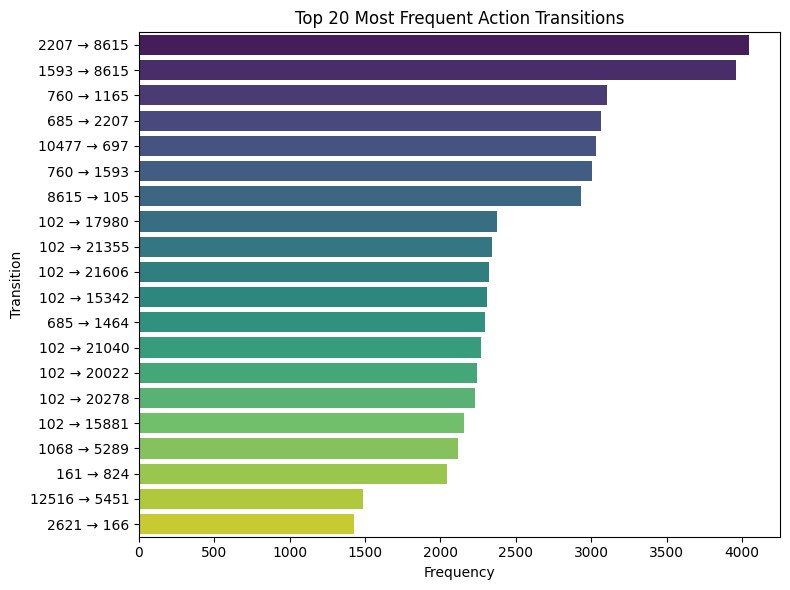

In [160]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# build transition pairs
pairs = [(seq[i], seq[i+1]) for seq in train_seqs for i in range(len(seq)-1)]

# count transitions
top = Counter(pairs).most_common(20)

# dataframe
top_df = pd.DataFrame(top, columns=["transition", "count"])

# convert tuple → readable string
top_df["transition"] = top_df["transition"].apply(lambda x: f"{x[0]} → {x[1]}")

# plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=top_df,
    x="count",
    y="transition",
    palette="viridis"
)

plt.title("Top 20 Most Frequent Action Transitions")
plt.xlabel("Frequency")
plt.ylabel("Transition")

plt.tight_layout()

Text(0, 0.5, 'Users')

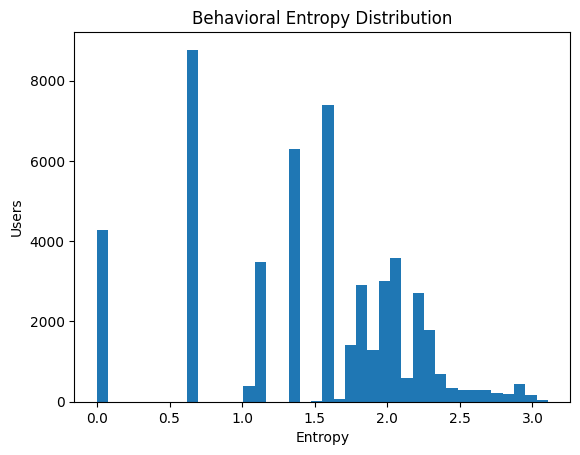

In [161]:
import scipy.stats as stats

def entropy(seq):
    if len(seq) == 0:
        return 0
    counts = np.bincount(seq)
    probs = counts / counts.sum()
    return stats.entropy(probs)

entropy_vals = [entropy(s) for s in train_seqs]

plt.hist(entropy_vals, bins=40)
plt.title("Behavioral Entropy Distribution")
plt.xlabel("Entropy")
plt.ylabel("Users")

Analyse First and Last Action

In [162]:
# Extract first and last action
train_df["first_action"] = train_df[seq_cols].apply(
    lambda row: row.dropna().values[0] if row.notna().any() else -1,
    axis=1
)

train_df["last_action"] = train_df[seq_cols].apply(
    lambda row: next((v for v in reversed(row.values) if v != 0), -1),
    axis=1
)

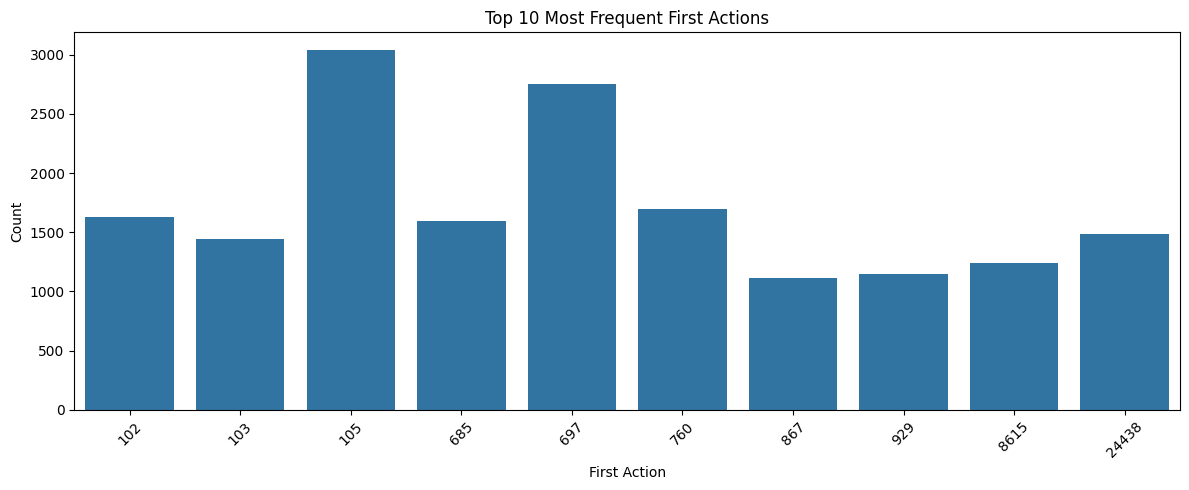

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

top_first = train_df["first_action"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_first.index,
    y=top_first.values
)

plt.title("Top 10 Most Frequent First Actions")
plt.xlabel("First Action")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

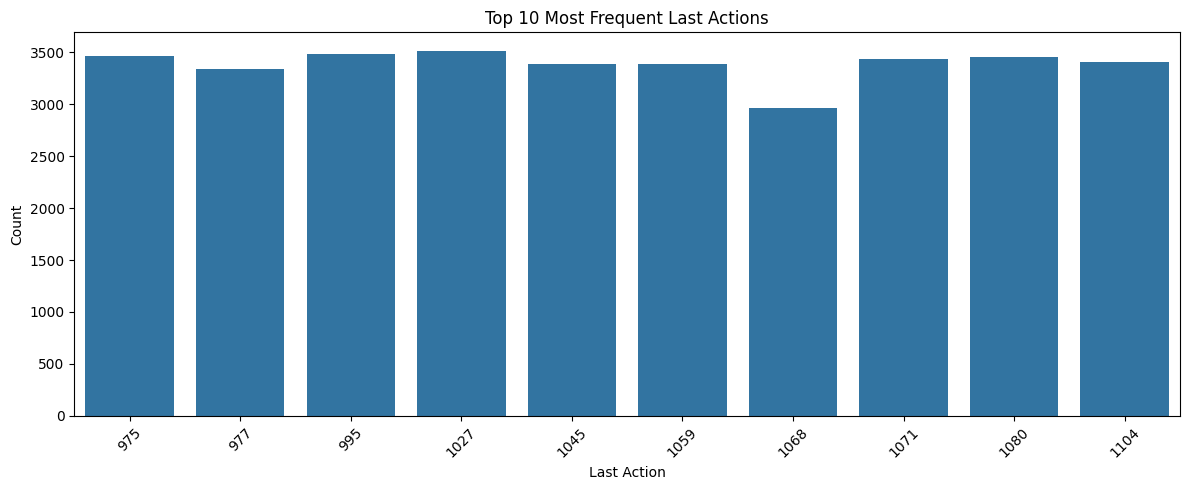

In [164]:
top_last = train_df["last_action"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_last.index,
    y=top_last.values
)

plt.title("Top 10 Most Frequent Last Actions")
plt.xlabel("Last Action")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

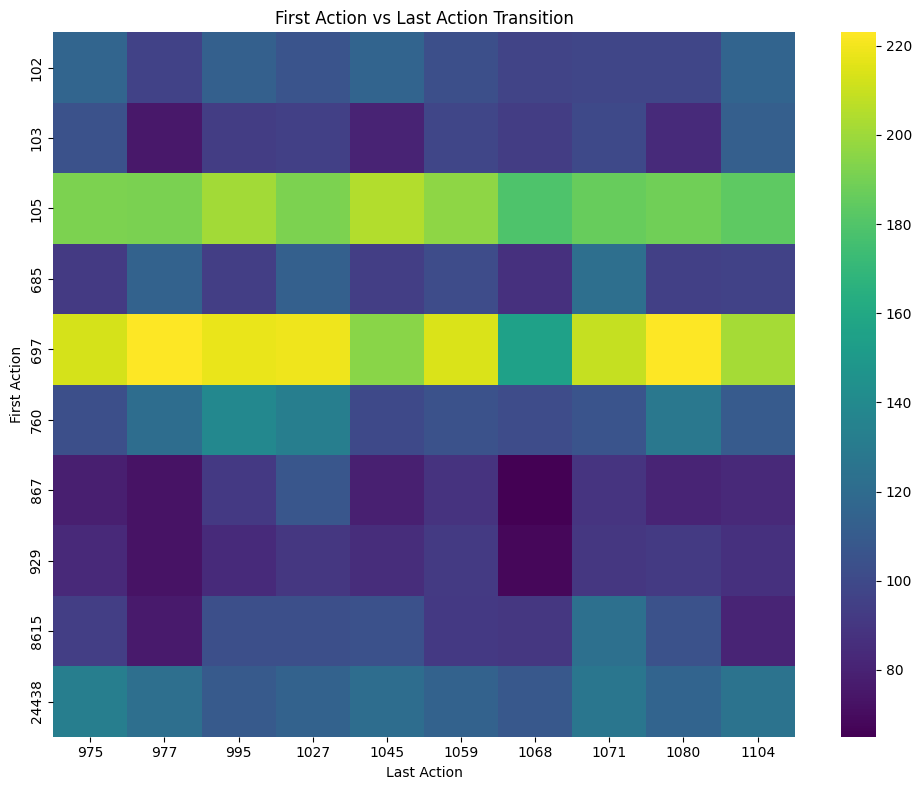

In [165]:
top_first = train_df["first_action"].value_counts().head(10).index
top_last  = train_df["last_action"].value_counts().head(10).index

subset = train_df[
    train_df["first_action"].isin(top_first) &
    train_df["last_action"].isin(top_last)
]

pivot = pd.crosstab(
    subset["first_action"],
    subset["last_action"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.title("First Action vs Last Action Transition")
plt.xlabel("Last Action")
plt.ylabel("First Action")

plt.tight_layout()

Position Impact

In [167]:
from sklearn.feature_selection import mutual_info_classif

MAX_POS = 10

position_tokens = []

for seq in train_seqs:
    padded = seq[:MAX_POS] + [-1]*(MAX_POS-len(seq))
    position_tokens.append(padded)

position_tokens = np.array(position_tokens)

mi_scores = {}

for i,col in enumerate(TARGET_COLS):
    
    y = Y_train[col]
    
    mi = []
    
    for pos in range(MAX_POS):
        x = position_tokens[:,pos].reshape(-1,1)
        score = mutual_info_classif(x, y, discrete_features=True)
        mi.append(score[0])
        
    mi_scores[col] = mi

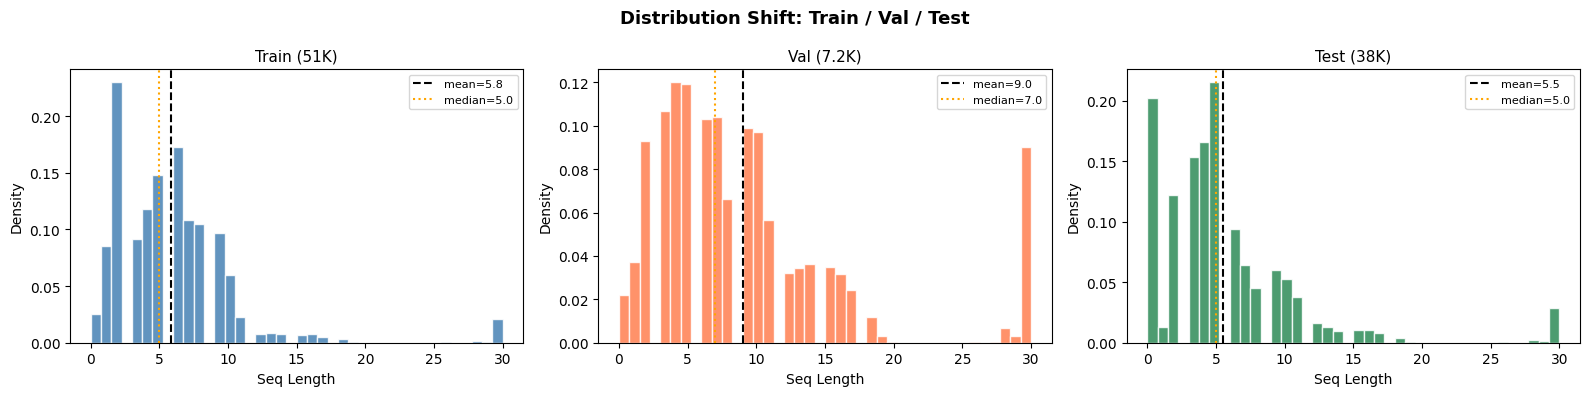

KS Test — Sequence Length Distribution:
  Train vs Val  : stat=0.2338  p=0.0000  SHIFT
  Train vs Test : stat=0.1328  p=0.0000  SHIFT
  Val vs Test   : stat=0.2819  p=0.0000  SHIFT


In [168]:
import scipy.stats as stats_mod

lengths_te = np.array([len(s) for s in test_seqs])

# ── 1. Sequence length distribution across 3 splits ──────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribution Shift: Train / Val / Test", fontsize=13, fontweight='bold')

for ax, lens, label, color in zip(
        axes,
        [lengths_tr, lengths_vl, lengths_te],
        ['Train (51K)', 'Val (7.2K)', 'Test (38K)'],
        ['steelblue', 'coral', 'seagreen']):
    ax.hist(lens, bins=40, color=color, edgecolor='white', alpha=0.85, density=True)
    ax.axvline(np.mean(lens),   color='black',  linestyle='--', lw=1.5,
               label=f'mean={np.mean(lens):.1f}')
    ax.axvline(np.median(lens), color='orange', linestyle=':',  lw=1.5,
               label=f'median={np.median(lens):.1f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Seq Length'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 2. KS test: Train vs Val vs Test seq length ───────────────────
ks_tv = stats_mod.ks_2samp(lengths_tr, lengths_vl)
ks_tt = stats_mod.ks_2samp(lengths_tr, lengths_te)
ks_vt = stats_mod.ks_2samp(lengths_vl, lengths_te)
print("KS Test — Sequence Length Distribution:")
print(f"  Train vs Val  : stat={ks_tv.statistic:.4f}  p={ks_tv.pvalue:.4f}  "
      f"{'SHIFT' if ks_tv.pvalue < 0.05 else 'OK'}")
print(f"  Train vs Test : stat={ks_tt.statistic:.4f}  p={ks_tt.pvalue:.4f}  "
      f"{'SHIFT' if ks_tt.pvalue < 0.05 else 'OK'}")
print(f"  Val vs Test   : stat={ks_vt.statistic:.4f}  p={ks_vt.pvalue:.4f}  "
      f"{'SHIFT' if ks_vt.pvalue < 0.05 else 'OK'}")

Token Position Impact Full Analysis

Kết nối với Model transformer: 
Model dùng `first_out`, `last_out`, `cls_out` + `PerAttrAttention`.  
Section này chứng minh bằng dữ liệu tại sao các vị trí đó quan trọng.


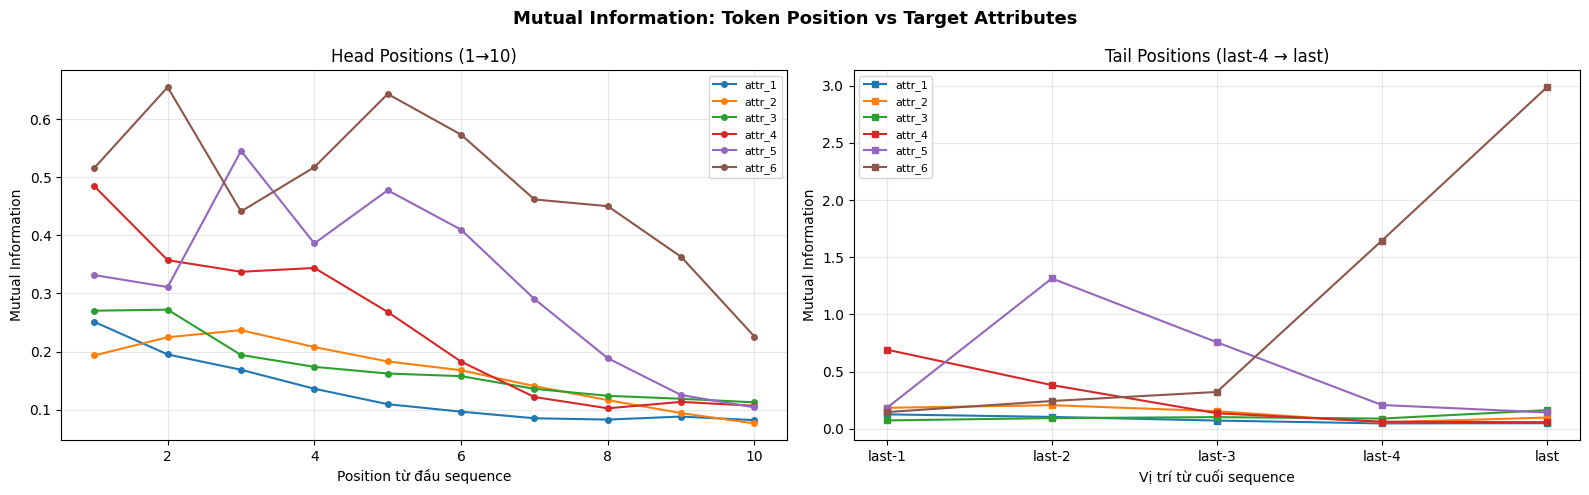

MI Summary — Top position per attribute:
Attr      Best Head Pos  MI_head │  Best Tail Pos  MI_tail
────────────────────────────────────────────────────────────
attr_1            pos 1   0.2511 │         last-1   0.1254
attr_2            pos 3   0.2367 │         last-2   0.2058
attr_3            pos 2   0.2721 │           last   0.1621
attr_4            pos 1   0.4844 │         last-1   0.6919
attr_5            pos 3   0.5452 │         last-2   1.3150
attr_6            pos 2   0.6548 │           last   2.9888


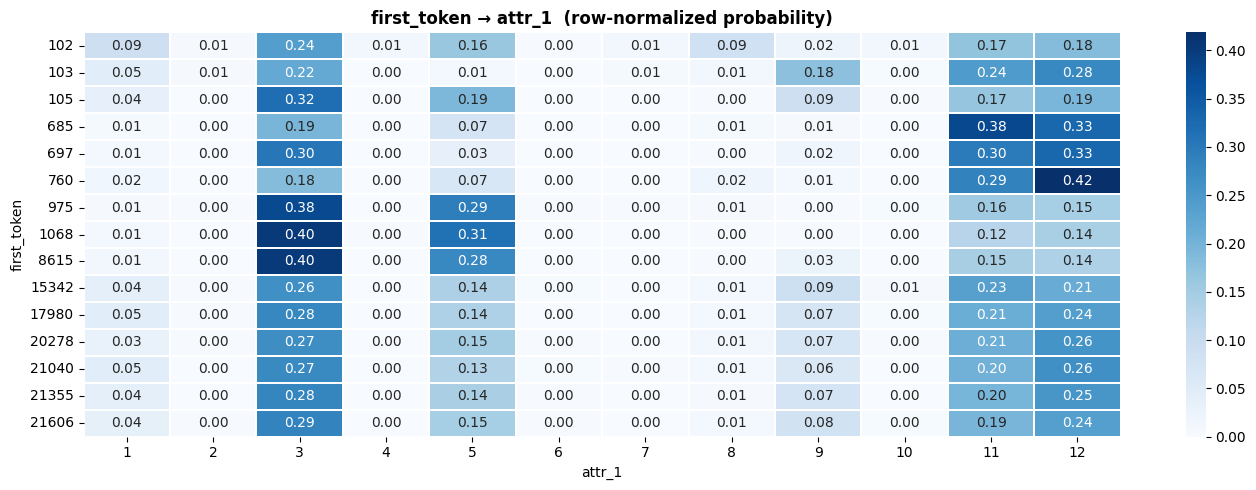


Top-5 most predictive (first_token → attr_1):
  first_token=102 → attr_1=3  (P=23.89%)
  first_token=103 → attr_1=12  (P=27.70%)
  first_token=105 → attr_1=3  (P=31.81%)
  first_token=685 → attr_1=11  (P=37.99%)
  first_token=697 → attr_1=12  (P=32.91%)


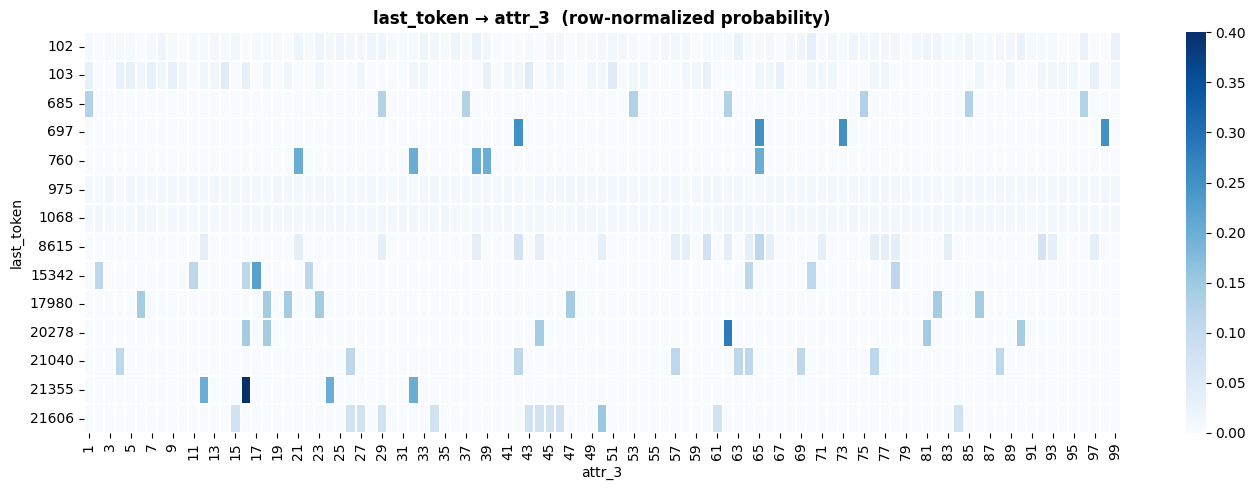


Top-5 most predictive (last_token → attr_3):
  last_token=102 → attr_3=70  (P=3.31%)
  last_token=103 → attr_3=14  (P=4.69%)
  last_token=685 → attr_3=1  (P=12.50%)
  last_token=697 → attr_3=42  (P=25.00%)
  last_token=760 → attr_3=21  (P=20.00%)


In [169]:
from sklearn.feature_selection import mutual_info_classif

# ── 1. Extended MI: cả đầu (pos 1-10) lẫn đuôi (last 5 pos) ──────
MAX_POS = 10

# Head positions (đã có trong notebook gốc, tính lại để dùng)
head_tokens = []
for seq in train_seqs:
    padded = seq[:MAX_POS] + [-1] * (MAX_POS - len(seq))
    head_tokens.append(padded)
head_tokens = np.array(head_tokens)

# Tail positions (MỚI)
TAIL_POS = 5
tail_tokens = []
for seq in train_seqs:
    tail = seq[-TAIL_POS:] if len(seq) >= TAIL_POS else ([-1]*(TAIL_POS-len(seq)) + seq)
    tail_tokens.append(tail)
tail_tokens = np.array(tail_tokens)

# Compute MI for head & tail
mi_head = {col: [] for col in TARGET_COLS}
mi_tail = {col: [] for col in TARGET_COLS}

for col in TARGET_COLS:
    y = Y_train[col]
    for pos in range(MAX_POS):
        x = head_tokens[:, pos].reshape(-1, 1)
        mi_head[col].append(mutual_info_classif(x, y, discrete_features=True)[0])
    for pos in range(TAIL_POS):
        x = tail_tokens[:, pos].reshape(-1, 1)
        mi_tail[col].append(mutual_info_classif(x, y, discrete_features=True)[0])

# Plot: head MI
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Mutual Information: Token Position vs Target Attributes", fontsize=13, fontweight='bold')

for col in TARGET_COLS:
    axes[0].plot(range(1, MAX_POS+1), mi_head[col], marker='o', markersize=4, label=col)
axes[0].set_title("Head Positions (1→10)")
axes[0].set_xlabel("Position từ đầu sequence")
axes[0].set_ylabel("Mutual Information")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

tail_labels = [f"last-{TAIL_POS-i}" for i in range(TAIL_POS-1, 0, -1)] + ["last"]
for col in TARGET_COLS:
    axes[1].plot(range(TAIL_POS), mi_tail[col], marker='s', markersize=4, label=col)
axes[1].set_title("Tail Positions (last-4 → last)")
axes[1].set_xticks(range(TAIL_POS)); axes[1].set_xticklabels(tail_labels)
axes[1].set_xlabel("Vị trí từ cuối sequence")
axes[1].set_ylabel("Mutual Information")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
print("MI Summary — Top position per attribute:")
print(f"{'Attr':<8} {'Best Head Pos':>14} {'MI_head':>8} │ {'Best Tail Pos':>14} {'MI_tail':>8}")
print("─" * 60)
for col in TARGET_COLS:
    bh = int(np.argmax(mi_head[col])) + 1
    bt_idx = int(np.argmax(mi_tail[col]))
    bt_label = tail_labels[bt_idx]
    print(f"{col:<8} {f'pos {bh}':>14} {mi_head[col][bh-1]:>8.4f} │ "
          f"{bt_label:>14} {mi_tail[col][bt_idx]:>8.4f}")

# ── 2. First token × attr_1 heatmap (direct evidence) ────────────
top_first_tokens = [t for t, _ in token_counter.most_common(15)]
train_df_local = X_train.merge(Y_train, on='id')
train_df_local['seq_len']     = train_df_local[seq_cols].notna().sum(axis=1)
train_df_local['first_token'] = [s[0] if len(s) > 0 else -1 for s in train_seqs]
train_df_local['last_token']  = [s[-1] if len(s) > 0 else -1 for s in train_seqs]

for token_pos, attr_target in [('first_token', 'attr_1'), ('last_token', 'attr_3')]:
    subset = train_df_local[train_df_local[token_pos].isin(top_first_tokens)]
    pivot = pd.crosstab(
        subset[token_pos],
        subset[attr_target],
        normalize='index'   # row %
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(pivot, cmap='Blues', ax=ax, linewidths=0.3,
                fmt='.2f', annot=(pivot.shape[1] <= 20))
    ax.set_title(f"{token_pos} → {attr_target}  (row-normalized probability)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(attr_target); ax.set_ylabel(token_pos)
    plt.tight_layout(); plt.show()

    # Print most predictive token→class pairs
    print(f"\nTop-5 most predictive ({token_pos} → {attr_target}):")
    for tok in pivot.index[:5]:
        best_class = pivot.loc[tok].idxmax()
        prob       = pivot.loc[tok].max()
        print(f"  {token_pos}={tok} → {attr_target}={best_class}  (P={prob:.2%})")

Rare Class Analysis — attr_3 & attr_6 (99 classes)

> Thách thức chính của bài toán:
> attr_3 và attr_6 có 99 classes, nhiều class chỉ có vài chục mẫu.  
> Section này khám phá imbalance và giải thích việc chọn model



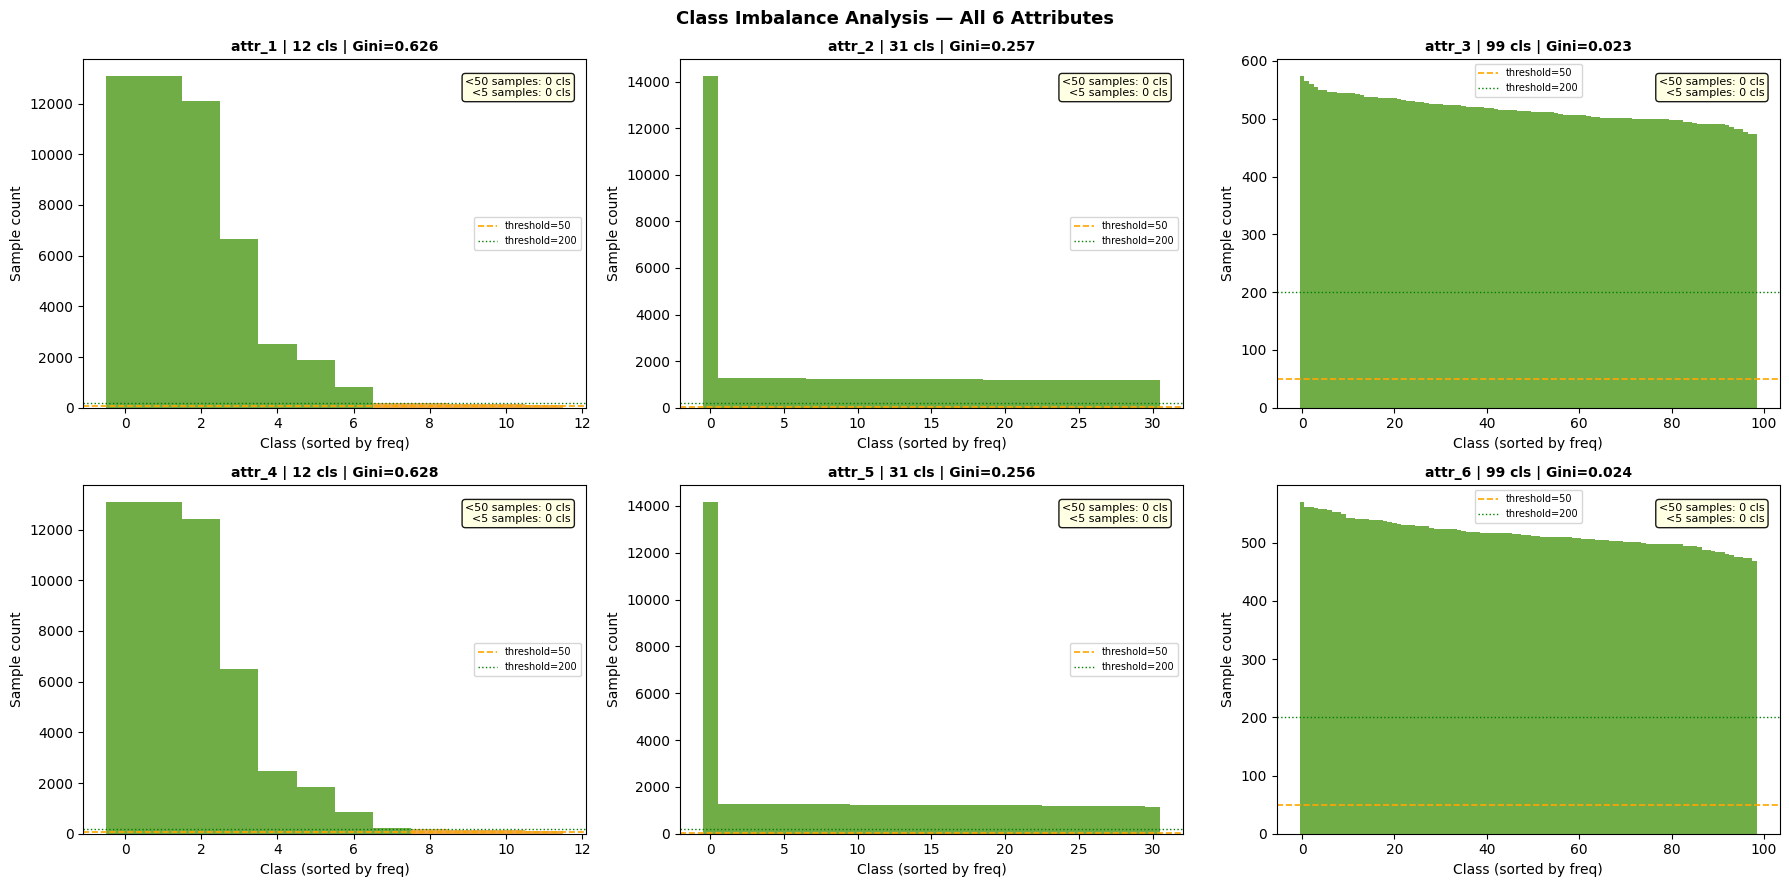

Attr     Classes   Gini  <5 samp  <50 samp  Top-1%  Bot-10%
────────────────────────────────────────────────────────────
attr_1        12  0.626        0         0   25.7%   48.69%
attr_2        31  0.257        0         0   27.9%   23.37%
attr_3        99  0.023        0         0    1.1%    9.48%
attr_4        12  0.628        0         0   25.7%   48.69%
attr_5        31  0.256        0         0   27.8%   23.33%
attr_6        99  0.024        0         0    1.1%    9.37%

attr_3 — Rare (<50) vs Common (≥200) sequences:
  Seq length : rare=nan  common=5.8  KS p=nan
  Entropy    : rare=nan   common=1.44    KS p=nan


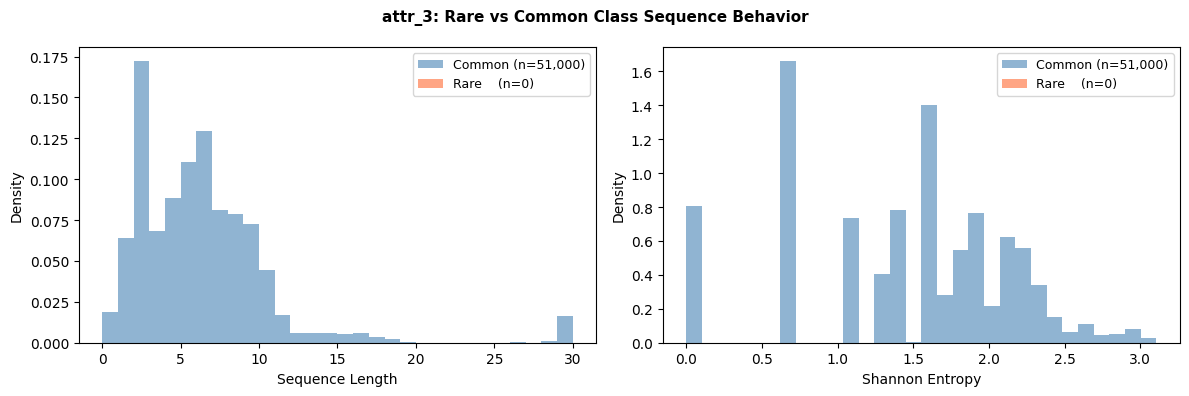


attr_6 — Rare (<50) vs Common (≥200) sequences:
  Seq length : rare=nan  common=5.8  KS p=nan
  Entropy    : rare=nan   common=1.44    KS p=nan


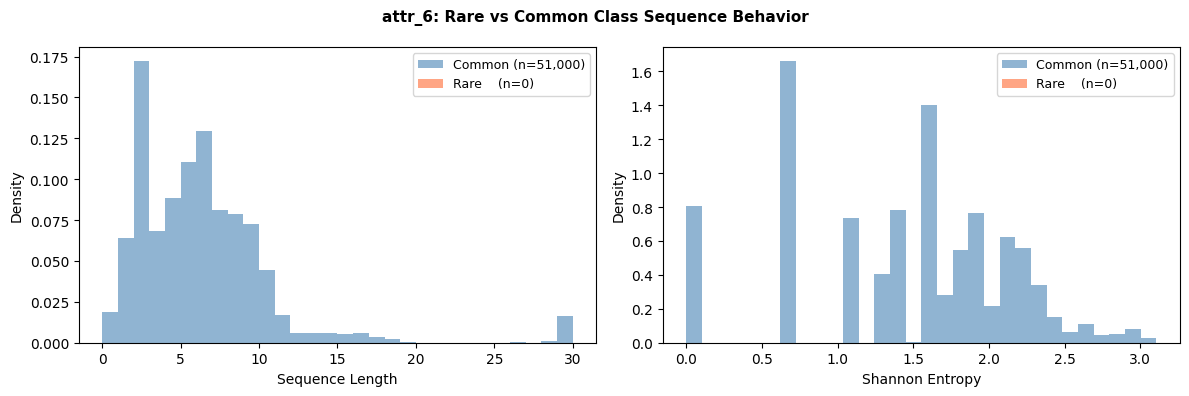

In [170]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("Class Imbalance Analysis — All 6 Attributes", fontsize=13, fontweight='bold')
imbalance_stats = {}
for i, col in enumerate(TARGET_COLS):
    ax   = axes[i // 3][i % 3]
    vc   = Y_train[col].value_counts().sort_values(ascending=False)
    n_cls = len(vc)

    # Lorenz-style: sort by count
    counts = vc.values
    cumsum = np.cumsum(counts) / counts.sum()

    # Gini coefficient
    n     = len(counts)
    index = np.arange(1, n + 1)
    gini  = (2 * np.sum(index * np.sort(counts)) / (n * counts.sum())) - (n + 1) / n

    # Rare class thresholds
    rare_5    = (vc < 5).sum()
    rare_50   = (vc < 50).sum()
    rare_100  = (vc < 100).sum()

    imbalance_stats[col] = {
        'n_classes': n_cls, 'gini': round(gini, 4),
        'rare_lt5': int(rare_5), 'rare_lt50': int(rare_50),
        'top1_pct': round(counts[0] / len(Y_train) * 100, 2),
        'bottom10_pct': round(counts[-min(10, n):].sum() / len(Y_train) * 100, 2),
    }

    # Plot: bar with rare threshold line
    bar_colors = ['#D9534F' if c < 50 else '#F0AD4E' if c < 200 else '#70AD47'
                  for c in counts]
    ax.bar(range(n_cls), counts, color=bar_colors, width=1.0, edgecolor='none')
    ax.axhline(50,  color='orange', linestyle='--', lw=1.2, label='threshold=50')
    ax.axhline(200, color='green',  linestyle=':',  lw=1.0, label='threshold=200')
    ax.set_title(f"{col} | {n_cls} cls | Gini={gini:.3f}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Class (sorted by freq)"); ax.set_ylabel("Sample count")
    ax.legend(fontsize=7)

    # Annotate rare count
    ax.text(0.97, 0.95, f"<50 samples: {rare_50} cls\n<5 samples: {rare_5} cls",
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

plt.tight_layout(); plt.show()

# Summary table
print(f"{'Attr':<8} {'Classes':>7} {'Gini':>6} {'<5 samp':>8} {'<50 samp':>9} "
      f"{'Top-1%':>7} {'Bot-10%':>8}")
print("─" * 60)
for col, s in imbalance_stats.items():
    print(f"{col:<8} {s['n_classes']:>7} {s['gini']:>6.3f} {s['rare_lt5']:>8} "
          f"{s['rare_lt50']:>9} {s['top1_pct']:>6.1f}% {s['bottom10_pct']:>7.2f}%")

# ── Rare classes: how do their sequences differ? ──────────────────
for col in ['attr_3', 'attr_6']:
    vc = Y_train[col].value_counts()
    rare_classes   = vc[vc < 50].index.tolist()
    common_classes = vc[vc >= 200].index.tolist()

    rare_idx   = Y_train[Y_train[col].isin(rare_classes)].index
    common_idx = Y_train[Y_train[col].isin(common_classes)].index

    rare_lens   = lengths_tr[rare_idx]
    common_lens = lengths_tr[common_idx]
    rare_ent    = np.array(entropy_vals)[rare_idx]
    common_ent  = np.array(entropy_vals)[common_idx]

    ks_len = stats_mod.ks_2samp(rare_lens, common_lens)
    ks_ent = stats_mod.ks_2samp(rare_ent, common_ent)

    print(f"\n{col} — Rare (<50) vs Common (≥200) sequences:")
    print(f"  Seq length : rare={rare_lens.mean():.1f}  common={common_lens.mean():.1f}  "
          f"KS p={ks_len.pvalue:.4f}")
    print(f"  Entropy    : rare={rare_ent.mean():.2f}   common={common_ent.mean():.2f}    "
          f"KS p={ks_ent.pvalue:.4f}")

    fig, axes2 = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{col}: Rare vs Common Class Sequence Behavior", fontsize=11, fontweight='bold')
    for ax, data_r, data_c, xlabel in zip(
            axes2,
            [rare_lens, rare_ent], [common_lens, common_ent],
            ['Sequence Length', 'Shannon Entropy']):
        ax.hist(data_c, bins=30, alpha=0.6, density=True,
                color='steelblue', label=f'Common (n={len(data_c):,})')
        ax.hist(data_r, bins=20, alpha=0.7, density=True,
                color='coral',     label=f'Rare    (n={len(data_r):,})')
        ax.set_xlabel(xlabel); ax.set_ylabel('Density')
        ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

Một số attribute (đặc biệt là attr_3) có số lượng class khá lớn nhưng phân phối của các class không thể hiện hiện tượng mất cân bằng nghiêm trọng theo dạng long-tail. Phần lớn các lớp vẫn có số lượng mẫu huấn luyện đủ lớn để mô hình có thể học được các pattern tương ứng.

Vì vậy, trong quá trình huấn luyện mô hình chúng tôi sử dụng CrossEntropyLoss tiêu chuẩn thay vì FocalLoss. FocalLoss thường chỉ mang lại lợi ích khi dữ liệu bị mất cân bằng rất mạnh, trong khi với phân phối hiện tại, CrossEntropyLoss vẫn đảm bảo khả năng học ổn định và hiệu quả.

Behavioral Personas

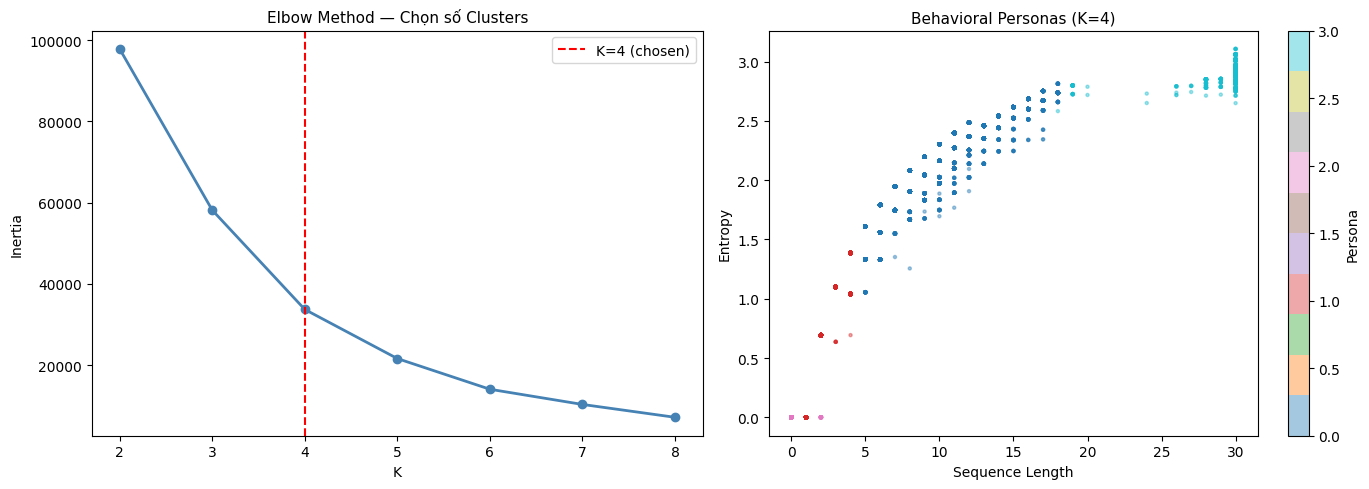

Persona Profiles:
         count  mean_len  mean_ent  mean_uratio
persona                                        
0        29050      7.60      1.89         0.93
1        20038      2.46      0.80         1.00
2          994      0.04      0.00         0.01
3          918     29.45      2.91         0.69

Business Persona Names:
  Persona 0 => Mixed Behavior
    count=29,050.0  mean_len=7.6  mean_entropy=1.89  unique_ratio=0.93
  Persona 1 => Standard User
    count=20,038.0  mean_len=2.5  mean_entropy=0.80  unique_ratio=1.00
  Persona 2 => Focused Buyer    (entropy thấp)
    count=994.0  mean_len=0.0  mean_entropy=0.00  unique_ratio=0.01
  Persona 3 => Comparison Shopper (entropy cao)
    count=918.0  mean_len=29.4  mean_entropy=2.91  unique_ratio=0.69


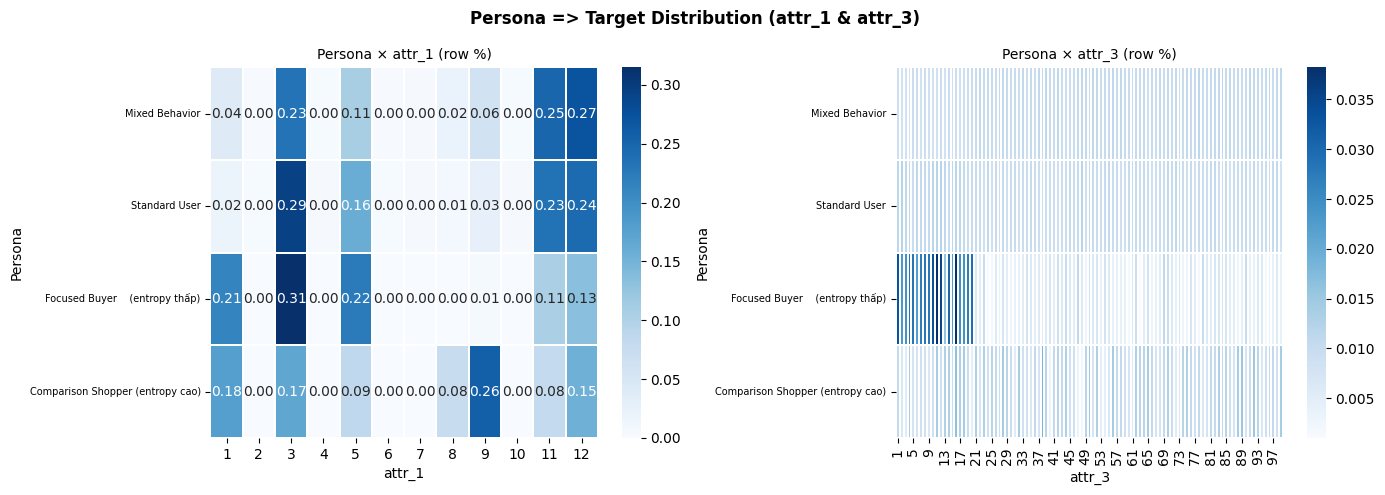

In [171]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Feature matrix: 4 features ───────────────────────────────────
train_df_p = X_train.merge(Y_train, on='id').copy()
train_df_p['seq_len']      = lengths_tr
train_df_p['entropy']      = entropy_vals
train_df_p['unique_ratio'] = [len(set(s)) / max(len(s), 1) for s in train_seqs]
train_df_p['first_token']  = [s[0]  if len(s) > 0 else -1 for s in train_seqs]

feat_cols  = ['seq_len', 'entropy', 'unique_ratio']
X_cluster  = StandardScaler().fit_transform(train_df_p[feat_cols])
# ── Elbow method to justify K=4 ───────────────────────────────────
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', lw=2)
axes[0].set_title("Elbow Method — Chọn số Clusters", fontsize=11)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].axvline(4, color='red', linestyle='--', label='K=4 (chosen)')
axes[0].legend()

# ── K=4 final clustering ──────────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
train_df_p['persona'] = km4.fit_predict(X_cluster)

# Scatter plot
scatter = axes[1].scatter(
    train_df_p['seq_len'], train_df_p['entropy'],
    c=train_df_p['persona'], cmap='tab10', alpha=0.4, s=5
)
axes[1].set_title("Behavioral Personas (K=4)", fontsize=11)
axes[1].set_xlabel("Sequence Length"); axes[1].set_ylabel("Entropy")
plt.colorbar(scatter, ax=axes[1], label='Persona')
plt.tight_layout(); plt.show()

# ── Persona profiling ─────────────────────────────────────────────
persona_profile = train_df_p.groupby('persona').agg(
    count      = ('seq_len', 'size'),
    mean_len   = ('seq_len', 'mean'),
    mean_ent   = ('entropy', 'mean'),
    mean_uratio= ('unique_ratio', 'mean'),
).round(2)
print("Persona Profiles:")
print(persona_profile.to_string())

# Business names based on profile
PERSONA_NAMES = {
    persona_profile['mean_len'].idxmin():    "Quick Browser    (ngắn, tập trung)",
    persona_profile['mean_len'].idxmax():    "Deep Explorer    (dài, phân tán)",
    persona_profile['mean_ent'].idxmin():    "Focused Buyer    (entropy thấp)",
    persona_profile['mean_ent'].idxmax():    "Comparison Shopper (entropy cao)",
}
# Handle overlap (4 clusters, 4 names)
used = set()
named = {}
for p_id, name in PERSONA_NAMES.items():
    if p_id not in used:
        named[p_id] = name
        used.add(p_id)
# Fill remaining
remaining_name = ["Mixed Behavior", "Standard User"]
ri = 0
for p_id in range(4):
    if p_id not in named:
        named[p_id] = remaining_name[ri]; ri += 1

print("\nBusiness Persona Names:")
for pid, name in sorted(named.items()):
    row = persona_profile.loc[pid]
    print(f"  Persona {pid} => {name}")
    print(f"    count={row['count']:,}  "
          f"mean_len={row['mean_len']:.1f}  "
          f"mean_entropy={row['mean_ent']:.2f}  "
          f"unique_ratio={row['mean_uratio']:.2f}")

# ── Persona × attr_1 distribution (link persona to business outcome) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Persona => Target Distribution (attr_1 & attr_3)", fontsize=12, fontweight='bold')

for ax, col in zip(axes, ['attr_1', 'attr_3']):
    pivot = pd.crosstab(train_df_p['persona'], train_df_p[col], normalize='index')
    sns.heatmap(pivot, cmap='Blues', ax=ax, linewidths=0.3,
                annot=(pivot.shape[1] <= 15), fmt='.2f')
    ax.set_title(f"Persona × {col} (row %)", fontsize=10)
    ax.set_xlabel(col); ax.set_ylabel("Persona")
    ax.set_yticklabels([named.get(int(t.get_text()), t.get_text())
                        for t in ax.get_yticklabels()],
                       fontsize=7, rotation=0)

plt.tight_layout(); plt.show()



Entropy as Prediction Difficulty Indicator

> **Cầu nối EDA → Model:** Section này CHỨNG MINH rằng entropy  
> (phát hiện trong EDA) trực tiếp liên quan đến độ khó dự đoán,  
> từ đó justify "Uncertainty Flag" trong deployment.

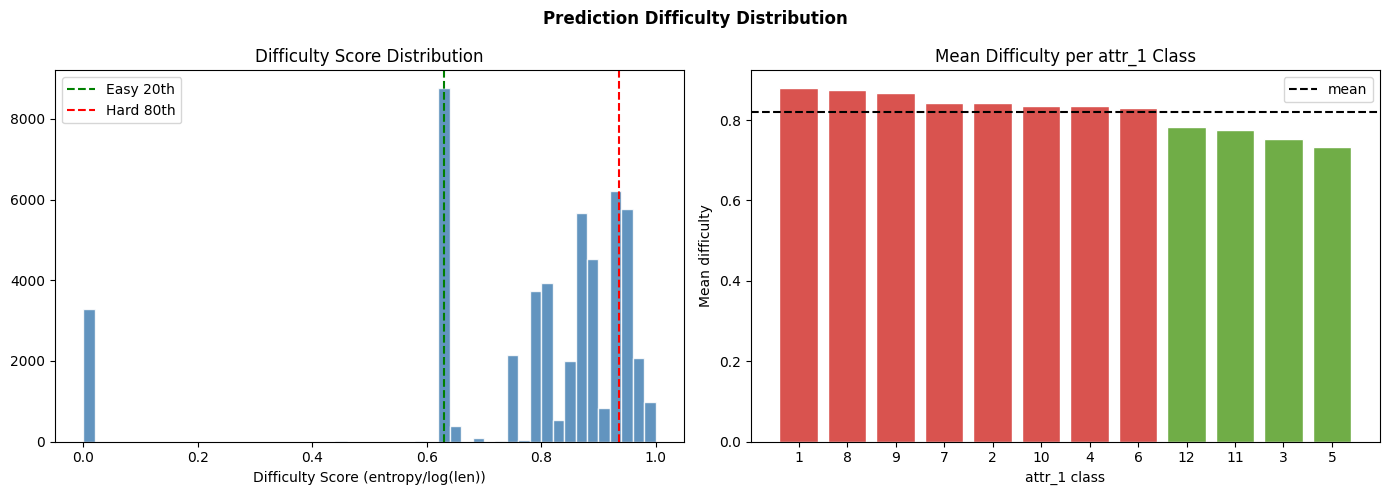

Sample count by difficulty tier:
  Very Easy   : 12,086 samples  (23.7%)
  Easy        : 10,256 samples  (20.1%)
  Medium      :  8,263 samples  (16.2%)
  Hard        : 11,345 samples  (22.2%)
  Very Hard   :  9,050 samples  (17.7%)


In [172]:
def prediction_difficulty_score(seq):
    """Higher = harder. Based on entropy + sequence length."""
    if len(seq) == 0:
        return 1.0
    ent = entropy(seq)
    # Short + high entropy = hardest
    length_factor = 1.0 / np.log1p(len(seq))
    return ent * length_factor

difficulty = np.array([prediction_difficulty_score(s) for s in train_seqs])
train_df_p['difficulty'] = difficulty

# Bin by difficulty
bins_d     = np.percentile(difficulty, [0, 20, 40, 60, 80, 100])
bin_labels_d = ['Very Easy', 'Easy', 'Medium', 'Hard', 'Very Hard']
train_df_p['difficulty_bin'] = pd.cut(
    difficulty, bins=bins_d, labels=bin_labels_d, include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prediction Difficulty Distribution", fontsize=12, fontweight='bold')

# Distribution of difficulty
axes[0].hist(difficulty, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
for p, c, lbl in [(20,'green','Easy 20th'), (80,'red','Hard 80th')]:
    axes[0].axvline(np.percentile(difficulty, p), color=c, linestyle='--',
                    lw=1.5, label=lbl)
axes[0].set_title("Difficulty Score Distribution"); axes[0].legend()
axes[0].set_xlabel("Difficulty Score (entropy/log(len))")

# Difficulty by attr_1 class (some classes are inherently harder)
diff_by_attr1 = train_df_p.groupby('attr_1')['difficulty'].mean().sort_values(ascending=False)
colors_diff = ['#D9534F' if v > diff_by_attr1.mean() else '#70AD47' for v in diff_by_attr1.values]
axes[1].bar(diff_by_attr1.index.astype(str), diff_by_attr1.values,
            color=colors_diff, edgecolor='white')
axes[1].axhline(diff_by_attr1.mean(), color='black', linestyle='--', lw=1.5, label='mean')
axes[1].set_title("Mean Difficulty per attr_1 Class")
axes[1].set_xlabel("attr_1 class"); axes[1].set_ylabel("Mean difficulty")
axes[1].legend()
plt.tight_layout(); plt.show()

# Count by bin
bin_counts = train_df_p['difficulty_bin'].value_counts().sort_index()
print("Sample count by difficulty tier:")
for tier, cnt in bin_counts.items():
    print(f"  {tier:<12}: {cnt:>6,} samples  ({100*cnt/len(train_seqs):.1f}%)")


## Phase 3: Anomaly Detection

In [173]:
# Identify anomalies based on sequence length
threshold = np.percentile(lengths_tr, 99)

anomalies = train_df[train_df["seq_len"] > threshold]

print("Number of anomalous sequences:", len(anomalies))

Number of anomalous sequences: 0


Repeated token spam

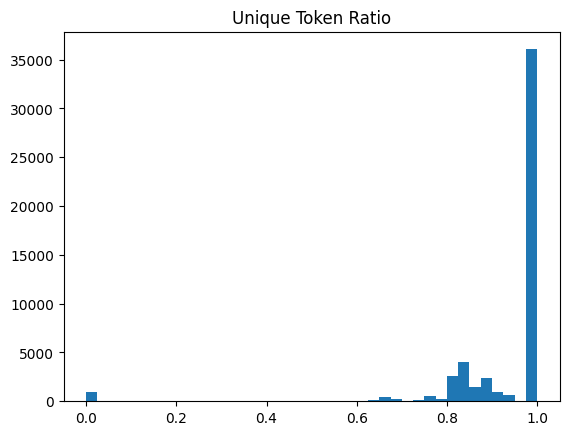

In [174]:
def repeated_ratio(seq):
    if len(seq) == 0:
        return 0
    return len(set(seq)) / len(seq)

train_df["unique_ratio"] = [repeated_ratio(s) for s in train_seqs]

plt.hist(train_df["unique_ratio"], bins=40)
plt.title("Unique Token Ratio")
plt.show()

In [175]:
spam_users = train_df[train_df["unique_ratio"] < 0.2]

print("Potential spam sequences:", len(spam_users))

Potential spam sequences: 974


Tức là xuất hiện users không có action nào

Entropy anomaly

In [176]:
from collections import Counter
import numpy as np

def calc_entropy(seq):
    if len(seq) == 0:
        return 0
    counts = Counter(seq)
    probs = np.array(list(counts.values())) / len(seq)
    return -(probs * np.log2(probs)).sum()
train_df["entropy"] = [calc_entropy(seq) for seq in train_seqs]

In [177]:
from sklearn.ensemble import IsolationForest

features = train_df[["seq_len","entropy"]]

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

train_df["anomaly_score"] = iso.fit_predict(features)

anomalies = train_df[train_df["anomaly_score"] == -1]

print("Isolation Forest anomalies:", len(anomalies))

Isolation Forest anomalies: 419


## Phase 4: Feature Importance

In [178]:
train_df["seq_len"] = [len(seq) for seq in train_seqs]
feature_df = train_df[["seq_len","entropy","unique_ratio"]]
for col in TARGET_COLS:
    corr = feature_df.join(Y_train[col]).corr()[col][:-1]
    print(col)
    print(corr)

attr_1
seq_len         0.022965
entropy         0.068228
unique_ratio    0.097401
Name: attr_1, dtype: float64
attr_2
seq_len         0.203084
entropy         0.191626
unique_ratio   -0.027229
Name: attr_2, dtype: float64
attr_3
seq_len         0.052701
entropy         0.091571
unique_ratio    0.081832
Name: attr_3, dtype: float64
attr_4
seq_len         0.026701
entropy         0.073553
unique_ratio    0.104658
Name: attr_4, dtype: float64
attr_5
seq_len         0.203006
entropy         0.191038
unique_ratio   -0.025391
Name: attr_5, dtype: float64
attr_6
seq_len         0.053079
entropy         0.090086
unique_ratio    0.082424
Name: attr_6, dtype: float64


<Axes: >

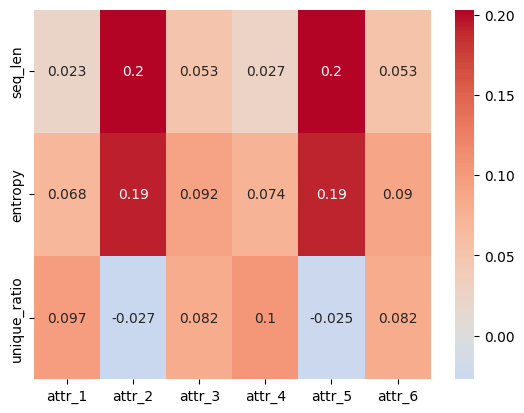

In [179]:
target_cols = Y_train.drop(columns=["id"], errors="ignore").columns
feature_df["seq_len"] = [len(seq) for seq in train_seqs]
corr = feature_df.join(Y_train[target_cols]).corr()

target_corr = corr.loc[feature_df.columns, target_cols]

sns.heatmap(
    target_corr,
    cmap="coolwarm",
    center=0,
    annot=True
)

In [180]:
X = train_df[["seq_len","entropy","unique_ratio"]]
for col in TARGET_COLS:

    y = Y_train[col]
    
    mi = mutual_info_classif(X, y)
    
    print(col)
    print(dict(zip(X.columns, mi)))

attr_1
{'seq_len': np.float64(0.08103514499281239), 'entropy': np.float64(0.11144343214976482), 'unique_ratio': np.float64(0.06571313854316596)}
attr_2
{'seq_len': np.float64(0.16477250182458647), 'entropy': np.float64(0.2075014662392194), 'unique_ratio': np.float64(0.08019380708777213)}
attr_3
{'seq_len': np.float64(0.03296991328191545), 'entropy': np.float64(0.04310866109480571), 'unique_ratio': np.float64(0.020478881945730443)}
attr_4
{'seq_len': np.float64(0.08298704173737903), 'entropy': np.float64(0.11222517004632904), 'unique_ratio': np.float64(0.06324213330779171)}
attr_5
{'seq_len': np.float64(0.1725125795989091), 'entropy': np.float64(0.21464020684504792), 'unique_ratio': np.float64(0.09245862241429714)}
attr_6
{'seq_len': np.float64(0.02122888575601589), 'entropy': np.float64(0.04877064940723308), 'unique_ratio': np.float64(0.024895867696593577)}


Có thể thấy:
entropy > seq_len > unique_ratio

Điều này nghĩa là độ đa dạng hành vi của người dùng quan trọng hơn số lượng hành động.

Tóm tắt các phát hiện từ EDA và quyết định thiết kế mô hình

Kết quả phân tích EDA cho thấy phần lớn các chuỗi hành vi của người dùng khá ngắn, với p95 của độ dài chuỗi vào khoảng 12. Do đó, trong quá trình thiết kế mô hình Transformer, chúng tôi đặt giới hạn chiều dài chuỗi tối đa (max length) là 12 để giảm padding không cần thiết và tăng hiệu quả tính toán.

Phân tích vị trí của các hành động trong chuỗi cho thấy những hành động xuất hiện ở giai đoạn đầu mang nhiều tín hiệu dự đoán quan trọng đối với các attributes mục tiêu. Điều này củng cố việc sử dụng cơ chế positional embedding trong mô hình để khai thác thông tin vị trí của hành vi người dùng.

Ngoài ra, entropy hành vi thể hiện mức độ đa dạng trong các tương tác của người dùng và cho thấy mối liên hệ nhất định với một số thuộc tính dự đoán. Vì vậy, entropy được đưa vào như một đặc trưng bổ trợ (auxiliary feature) trong mô hình.

Phân tích dữ liệu cũng cho thấy mức độ đa dạng của các hành động trong chuỗi thay đổi khá lớn giữa các người dùng. Để phản ánh đặc điểm này, chúng tôi xây dựng thêm đặc trưng unique_ratio nhằm đo lường tỷ lệ hành động khác nhau trong mỗi chuỗi.


Cuối cùng, mặc dù một số thuộc tính có số lượng lớp tương đối lớn, phân phối tổng thể của các lớp không thể hiện tình trạng mất cân bằng nghiêm trọng. Vì vậy, trong quá trình huấn luyện mô hình, chúng tôi sử dụng hàm mất mát CrossEntropyLoss thay vì các biến thể như Focal Loss vốn thường chỉ hiệu quả trong trường hợp dữ liệu bị mất cân bằng mạnh.

encoding và save outputs

In [181]:
import os
import pickle

# CREATE SAVE DIRECTORY

BASE_DIR = os.getcwd()  
PIPELINE_DIR = os.path.join(BASE_DIR, "pipeline_data")

os.makedirs(PIPELINE_DIR, exist_ok=True)


# ENCODE TARGETS
from sklearn.preprocessing import LabelEncoder

encoders = {}

Y_train_enc = Y_train.copy()
Y_val_enc   = Y_val.copy()

for col in TARGET_COLS:
    le = LabelEncoder()
    Y_train_enc[col] = le.fit_transform(Y_train[col])
    Y_val_enc[col]   = le.transform(Y_val[col])
    encoders[col]    = le


# SAVE FILES
# sequences
with open(os.path.join(PIPELINE_DIR, "sequences.pkl"), "wb") as f:
    pickle.dump({
        "train": train_seqs,
        "val": val_seqs,
        "test": test_seqs
    }, f)

# metadata
with open(os.path.join(PIPELINE_DIR, "meta.pkl"), "wb") as f:
    pickle.dump({
        "meta_cols": meta_cols,
        "seq_cols": seq_cols,
        "max_len_p95": MAX_LEN_P95,
        "N_train": N_train
    }, f)

# label encoders
with open(os.path.join(PIPELINE_DIR, "encoders.pkl"), "wb") as f:
    pickle.dump(encoders, f)

# token statistics
with open(os.path.join(PIPELINE_DIR, "token_stats.pkl"), "wb") as f:
    pickle.dump({
        "counter": token_counter,
        "very_common": very_common,
        "common": common,
        "rare": rare
    }, f)

# encoded labels
Y_train_enc.to_csv(os.path.join(PIPELINE_DIR, "Y_train_enc.csv"), index=False)
Y_val_enc.to_csv(os.path.join(PIPELINE_DIR, "Y_val_enc.csv"), index=False)

# original labels
Y_train.to_csv(os.path.join(PIPELINE_DIR, "Y_train_orig.csv"), index=False)
Y_val.to_csv(os.path.join(PIPELINE_DIR, "Y_val_orig.csv"), index=False)


print("Saved pipeline outputs to:", PIPELINE_DIR)

print("""
Saved files:
   sequences.pkl
   meta.pkl
   encoders.pkl
   token_stats.pkl
   Y_train_enc.csv
   Y_val_enc.csv
   Y_train_orig.csv
   Y_val_orig.csv
""")


Saved pipeline outputs to: d:\User Behavior Analysis\pipeline_data

Saved files:
   sequences.pkl
   meta.pkl
   encoders.pkl
   token_stats.pkl
   Y_train_enc.csv
   Y_val_enc.csv
   Y_train_orig.csv
   Y_val_orig.csv

